# Model Development
Sprint Day 4-5 — ML Demand Forecasting Platform

Goal: predict `units_sold` using engineered features. Train and compare Linear Regression, Random Forest, and XGBoost. Use a **time-based split** (not random) since this is a forecasting problem — training on the past to predict the future, matching how the model will actually be used.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

os.makedirs("../models", exist_ok=True)

df = pd.read_csv("../data/cleaned_sales_dataset.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
print(df.shape)
df.head()

(36480, 14)


,date,store,product,price,promo,units_sold,revenue,is_outlier,store_encoded,product_encoded,day_of_week,month,year,is_weekend
0,2023-01-01,Store_1,Product_A,37.94,0,196.0,7417.96,False,0,0,6,1,2023,1
1,2023-01-01,Store_3,Product_A,38.56,0,204.0,7885.51,False,2,0,6,1,2023,1
2,2023-01-01,Store_3,Product_B,45.74,0,86.0,3927.39,False,2,1,6,1,2023,1
3,2023-01-01,Store_4,Product_B,41.86,0,135.0,5655.49,False,3,1,6,1,2023,1
4,2023-01-01,Store_4,Product_F,19.34,0,88.0,1705.27,False,3,5,6,1,2023,1


## 1. Feature Selection & Time-Based Train/Test Split
Last 15% of the date range (by time, not randomly) becomes the test set — this mimics real forecasting, where you always predict days you haven't seen yet.

In [2]:
FEATURES = ["store_encoded", "product_encoded", "price", "promo",
            "day_of_week", "month", "is_weekend"]
TARGET = "units_sold"

cutoff_date = df["date"].quantile(0.85, interpolation="nearest")
train_df = df[df["date"] <= cutoff_date]
test_df = df[df["date"] > cutoff_date]

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train dates: {train_df['date'].min().date()} -> {train_df['date'].max().date()}")
print(f"Test dates:  {test_df['date'].min().date()} -> {test_df['date'].max().date()}")

Train: (31040, 7), Test: (5440, 7)
Train dates: 2023-01-01 -> 2025-02-14
Test dates:  2025-02-15 -> 2025-06-30


## 2. Baseline: Linear Regression

In [3]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
print("Linear Regression trained.")

Linear Regression trained.


## 3. Random Forest (with light hyperparameter tuning)
Using `RandomizedSearchCV` over a small grid rather than a full grid search — keeps tuning time reasonable while still improving on defaults.

In [4]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [8, 12, 16],
    "min_samples_split": [2, 5, 10],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    n_iter=6,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
rf = rf_search.best_estimator_
rf_preds = rf.predict(X_test)
print("Best RF params:", rf_search.best_params_)

Best RF params: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 16}


## 4. XGBoost (with light hyperparameter tuning)

In [5]:
xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, objective="reg:squarederror"),
    xgb_param_grid,
    n_iter=6,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
)
xgb_search.fit(X_train, y_train)
xgb_model = xgb_search.best_estimator_
xgb_preds = xgb_model.predict(X_test)
print("Best XGB params:", xgb_search.best_params_)

Best XGB params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}


## 5. Compare Models

In [6]:
def evaluate(name, y_true, y_pred):
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

results = pd.DataFrame([
    evaluate("Linear Regression", y_test, lr_preds),
    evaluate("Random Forest", y_test, rf_preds),
    evaluate("XGBoost", y_test, xgb_preds),
]).set_index("model").round(3)

results

,MAE,RMSE,R2
model,,,
Linear Regression,43.999,59.384,0.058
Random Forest,11.236,28.467,0.784
XGBoost,9.999,27.449,0.799


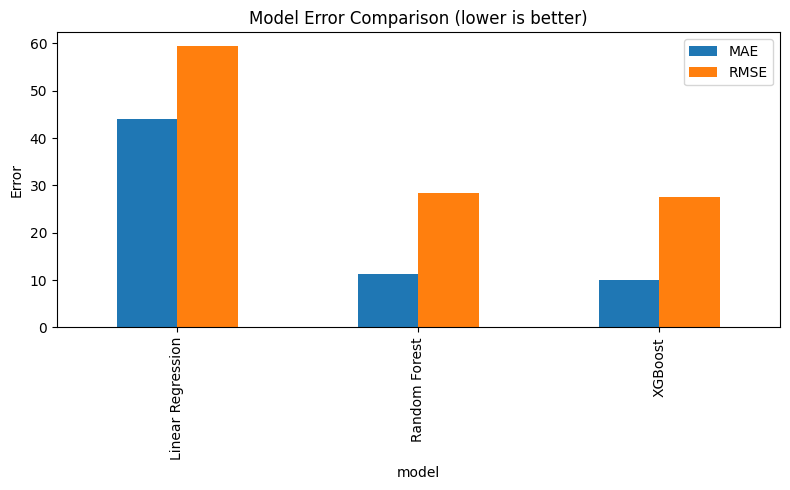

In [7]:
results[["MAE", "RMSE"]].plot(kind="bar", figsize=(8, 5), title="Model Error Comparison (lower is better)")
plt.ylabel("Error")
plt.tight_layout()
plt.savefig("../docs/model_comparison.png", dpi=120)
plt.show()

## 6. Feature Importance (best model)

Best model by MAE: XGBoost


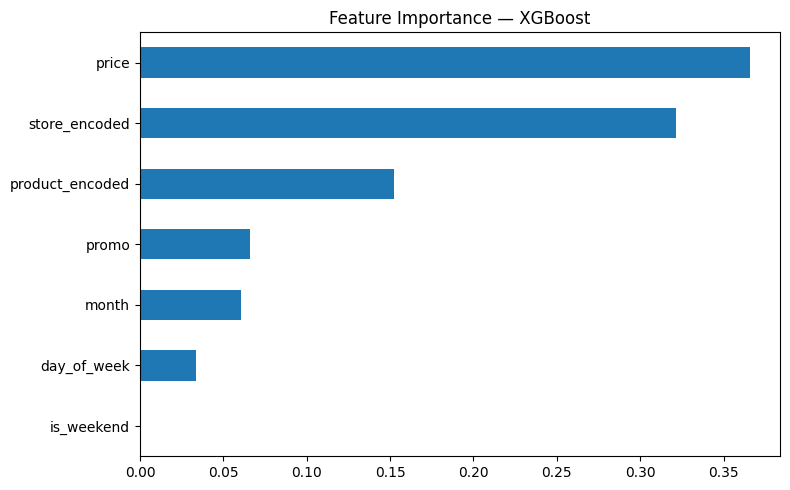

In [8]:
best_model_name = results["MAE"].idxmin()
print("Best model by MAE:", best_model_name)

model_map = {"Linear Regression": lr, "Random Forest": rf, "XGBoost": xgb_model}
best_model = model_map[best_model_name]

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()
    importances.plot(kind="barh", figsize=(8, 5), title=f"Feature Importance — {best_model_name}")
    plt.tight_layout()
    plt.savefig("../docs/feature_importance.png", dpi=120)
    plt.show()
else:
    coefs = pd.Series(best_model.coef_, index=FEATURES).sort_values()
    coefs.plot(kind="barh", figsize=(8, 5), title=f"Coefficients — {best_model_name}")
    plt.tight_layout()
    plt.savefig("../docs/feature_importance.png", dpi=120)
    plt.show()

## 7. Actual vs Predicted (best model)

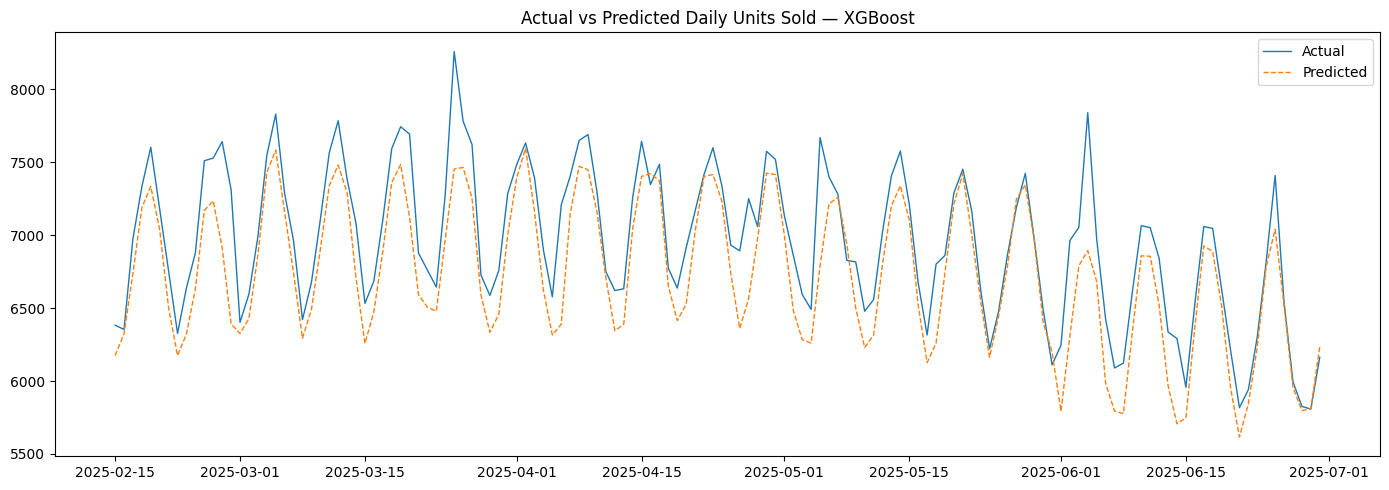

In [9]:
plt.figure(figsize=(14, 5))
sample = test_df.groupby("date")["units_sold"].sum().reset_index()
pred_series = test_df.copy()
pred_series["predicted"] = best_model.predict(X_test)
pred_daily = pred_series.groupby("date")["predicted"].sum().reset_index()

plt.plot(sample["date"], sample["units_sold"], label="Actual", linewidth=1)
plt.plot(pred_daily["date"], pred_daily["predicted"], label="Predicted", linewidth=1, linestyle="--")
plt.legend()
plt.title(f"Actual vs Predicted Daily Units Sold — {best_model_name}")
plt.tight_layout()
plt.savefig("../docs/actual_vs_predicted.png", dpi=120)
plt.show()

## 8. Save Models

In [10]:
joblib.dump(lr, "../models/linear_regression.joblib")
joblib.dump(rf, "../models/random_forest.joblib")
joblib.dump(xgb_model, "../models/xgboost.joblib")

results.to_csv("../docs/model_comparison_results.csv")

print("Models saved to /models")
print(f"\nBest model: {best_model_name}")
results

Models saved to /models

Best model: XGBoost


,MAE,RMSE,R2
model,,,
Linear Regression,43.999,59.384,0.058
Random Forest,11.236,28.467,0.784
XGBoost,9.999,27.449,0.799


## Summary
- Used a **time-based split** (not random) since this is a forecasting task
- Compared 3 models: Linear Regression (baseline), Random Forest, XGBoost
- Light `RandomizedSearchCV` tuning on RF and XGBoost (6 iterations, 3-fold CV each) — a full grid search was skipped to keep training time reasonable for the sprint
- Best model selected by MAE on the held-out (future) test period
- All 3 trained models saved to `/models` for the API's `/predict` endpoint (Day 7)